### This document is to make sure BRFSS data - from previous step is prepped to answer 2 main questions -

#### 1.  Can reduction in MEDCOST by XX, XX, XX percentages yield to a substantial policy recommendations (Scenario - Expanded Insurance Coverage / Removal of Cost Barriers)
#### 2.  Can offering QuitLine services/ Digital Support by varying VAR by XX, XX and XX percentages yield to a substantial policy recommendation. (Scenario - Integrated Quitline & Clinical Digital Support)



## 1. Wrangle data to make sure we have all features in a clean dataset to evaluate effect of MEDCOST on smoking rates

1. Evaluate relationship between MEDCOST and _RFSMOKE dataset after performing EDA

1. Manage imports<br<>>
2. Read data<br>



In [6]:
import pandas as pd

In [1]:
import pickle

# Replace '002-eda_final.pkl' with the actual filename if different
with open('../data/processed/002-eda_final.pkl', 'rb') as f:
    df = pickle.load(f)

df.head() # Display the first few rows of the DataFrame to verify successful loading

,DISPCODE,GENHLTH,PHYSHLTH,MENTHLTH,HLTHPLN1,PERSDOC2,MEDCOST,CHECKUP1,CVDINFR4,CVDCRHD4,...,_EDUCAG,_INCOMG,_RFSMOK3,DRNKANY5,_RFBING5,_TOTINDA,_RFSEAT3,YEAR,DIABETES,_AGE65YR
0,1200,5,3,4,1,1,2,1,2,2,...,2,2,0,2,1,2,1,2015,2,1
1,1100,3,1,1,2,1,1,4,2,2,...,4,1,1,2,1,1,2,2015,2,1
3,1100,5,4,4,1,2,1,1,2,2,...,2,5,0,2,1,2,1,2015,2,1
4,1100,5,4,1,1,1,2,1,2,2,...,3,5,0,2,1,2,1,2015,2,1
5,1100,2,1,1,1,1,2,1,2,2,...,1,4,0,2,1,1,1,2015,2,2


In [2]:
df.shape # Display the shape of the DataFrame to understand its dimensions

(2311512, 49)

<Axes: xlabel='MEDCOST'>

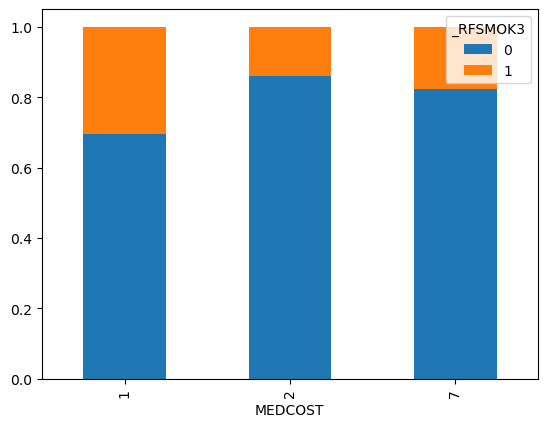

In [7]:
# Create a crosstab to evaluate the relationship between MEDCOST and _RFSMOK3
medcost_smoke_ct = pd.crosstab(df['MEDCOST'], df['_RFSMOK3'], normalize='index')
medcost_smoke_ct.plot(kind='bar', stacked=True)

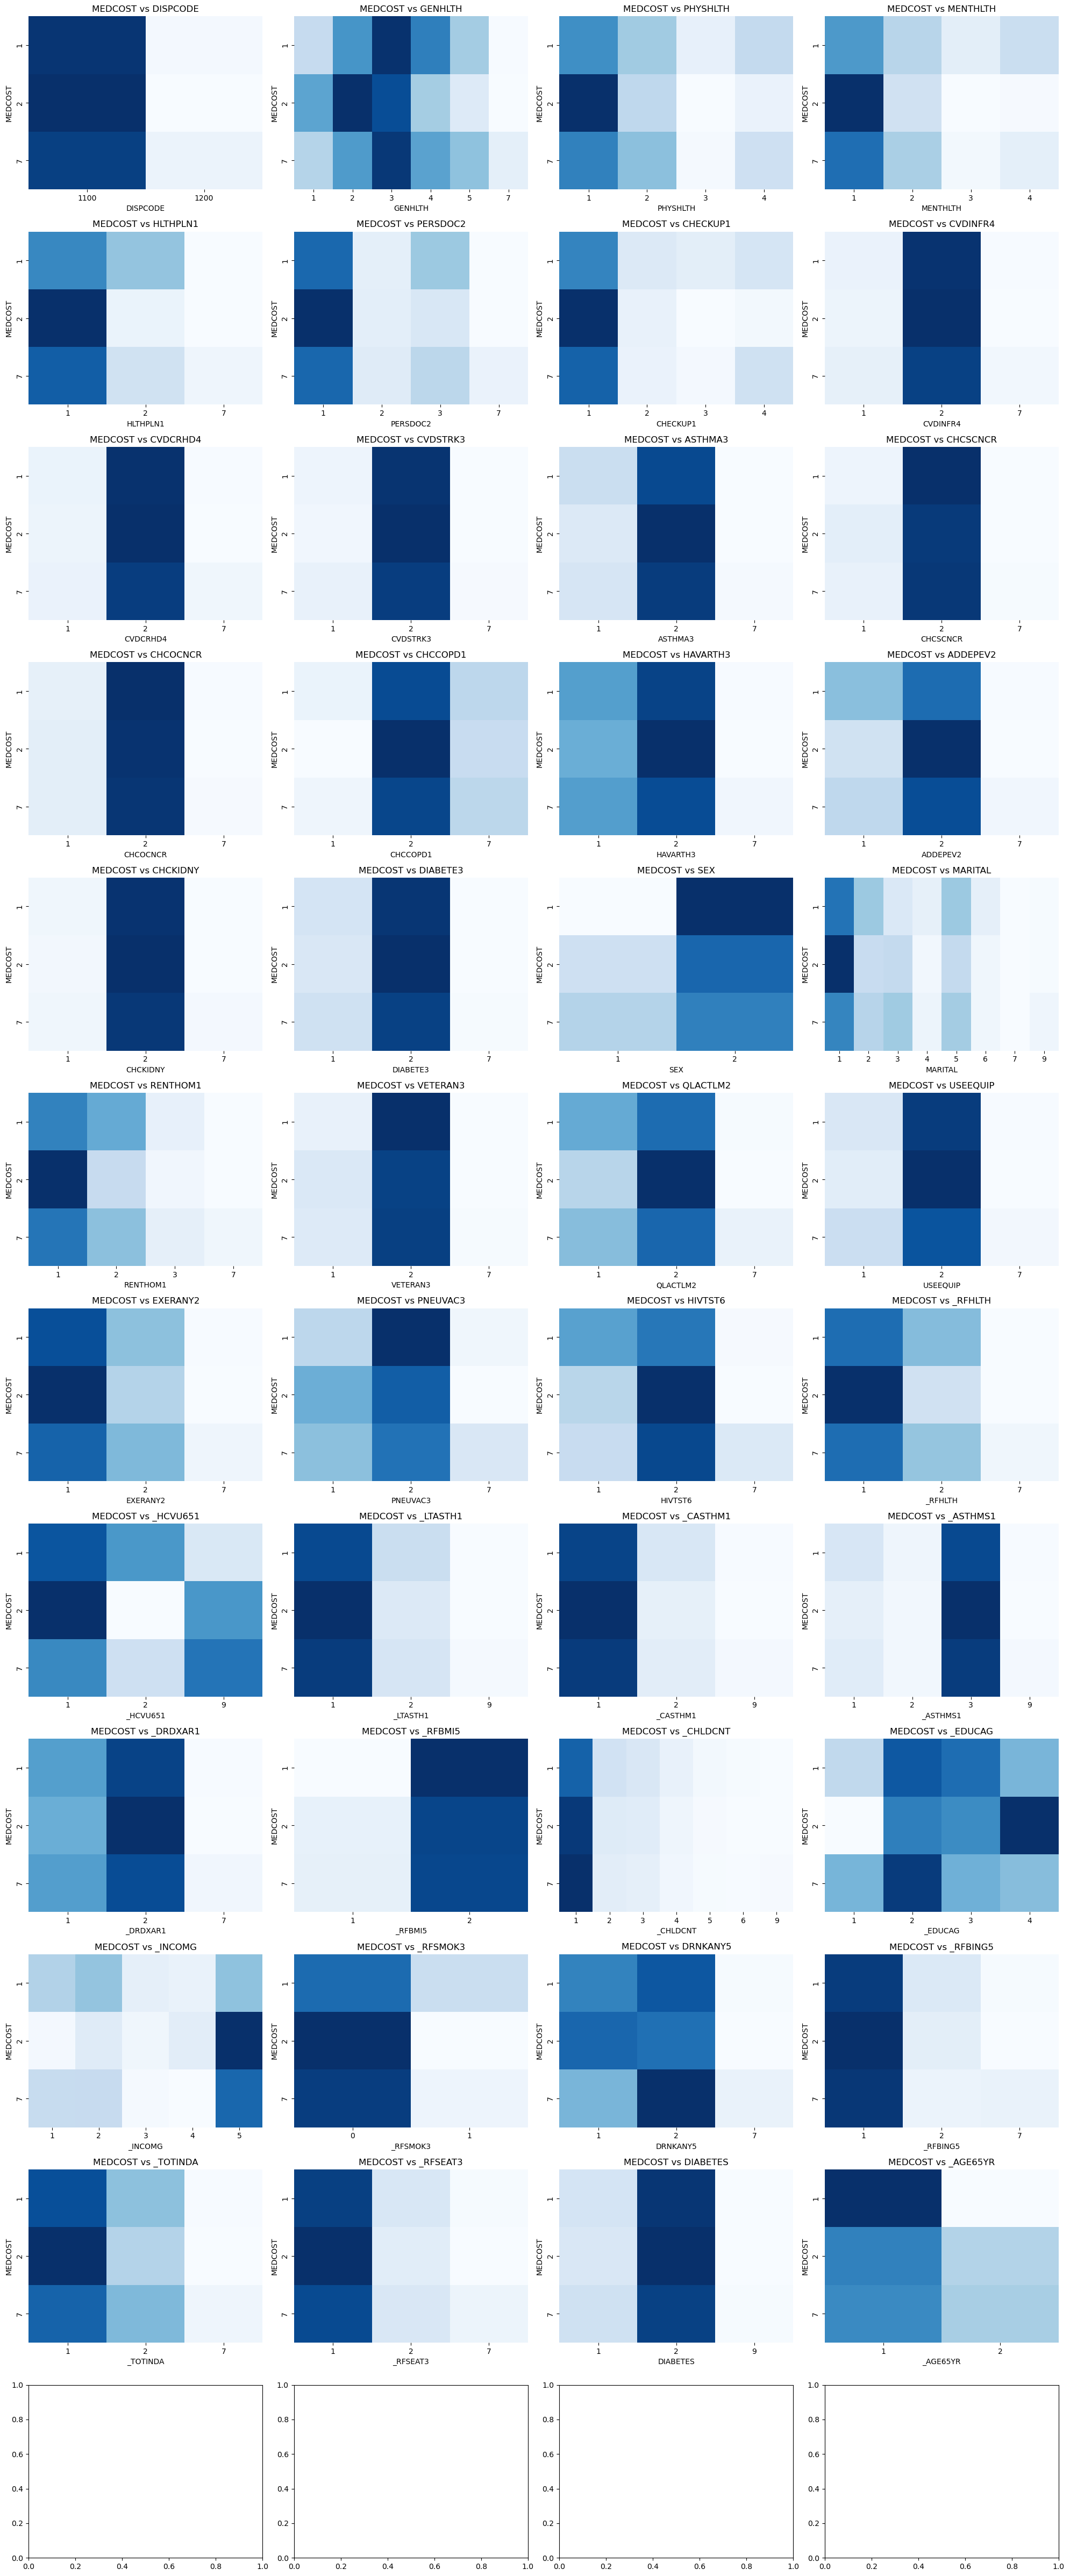

In [9]:
import seaborn as sns

import matplotlib.pyplot as plt

# Select categorical features excluding MEDCOST
features = [f for f in df.columns if f != 'MEDCOST' and df[f].dtype.name == 'category']

# Calculate mean value of each feature grouped by MEDCOST
feature_means = {}
for f in features:
    # For each category in feature, calculate proportion per MEDCOST
    ct = pd.crosstab(df['MEDCOST'], df[f], normalize='index')
    feature_means[f] = ct

# Plot heatmaps for each feature
fig, axes = plt.subplots(nrows=len(features)//4 + 1, ncols=4, figsize=(20, 4*(len(features)//4 + 1)))
axes = axes.flatten()

for i, f in enumerate(features):
    sns.heatmap(feature_means[f], ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f'MEDCOST vs {f}')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('MEDCOST')

plt.tight_layout()
plt.show()